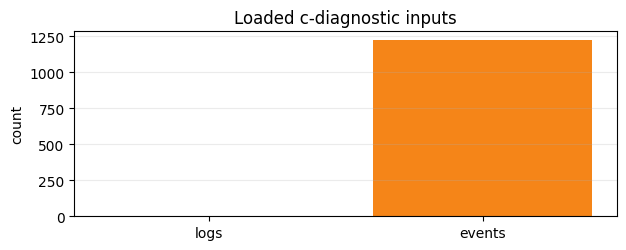

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "lora_playground").exists():
    ROOT = ROOT.parent

DEFAULT_LOGS = [
    ROOT / "logs/bench_ssc_drift/v5_bs32_kpar_split_K3_R5W5_n10eval20_h10_p2_r256_lr3e-2_100_DIAG_ema0p8_warmreset.log",
    ROOT / "logs/bench_ssc_drift/debug_bs32_kpar_K3R5_p2_nan_trace_2k.log",
    ROOT / "logs/bench_ssc_drift/debug_bs32_kpar_K3R5_p2_nan_window.log",
]
LOGS = [p for p in DEFAULT_LOGS if p.exists()]

def read_events(paths):
    rows = []
    for path in paths:
        with path.open() as fh:
            for line in fh:
                try:
                    obj = json.loads(line)
                except json.JSONDecodeError:
                    continue
                obj["source"] = path.name
                rows.append(obj)
    return rows

events = read_events(LOGS)
print(f"Loaded {len(events)} JSONL events from {len(LOGS)} log file(s).")
for path in LOGS:
    print(path.relative_to(ROOT))


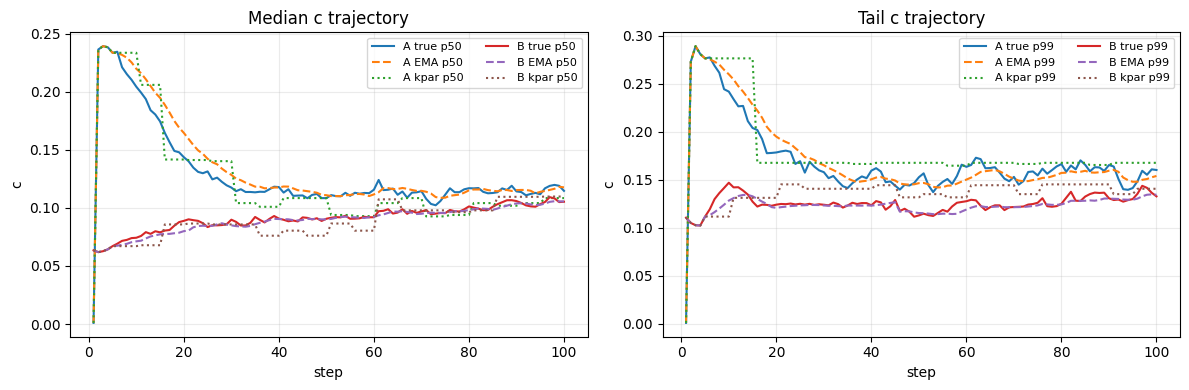

In [2]:
agg = pd.DataFrame([e for e in events if e.get("event") == "ssc_c_diag"])
if agg.empty:
    fig, ax = plt.subplots(figsize=(8, 2.6))
    ax.text(0.5, 0.5, "No ssc_c_diag records found", ha="center", va="center")
    ax.set_axis_off()
else:
    for col in ("step", "n"):
        agg[col] = pd.to_numeric(agg[col], errors="coerce")
    plot_df = agg[(agg["step"] >= 1) & (agg["n"] == agg["n"].max())].copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    for side, sub in plot_df.groupby("side"):
        by_step = sub.groupby("step", as_index=False)[[
            "c_true_p50", "c_true_p99", "c_ema_p50", "c_ema_p99", "c_used_p50", "c_used_p99"
        ]].median(numeric_only=True)
        axes[0].plot(by_step["step"], by_step["c_true_p50"], label=f"{side} true p50")
        axes[0].plot(by_step["step"], by_step["c_ema_p50"], ls="--", label=f"{side} EMA p50")
        axes[0].plot(by_step["step"], by_step["c_used_p50"], ls=":", label=f"{side} kpar p50")
        axes[1].plot(by_step["step"], by_step["c_true_p99"], label=f"{side} true p99")
        axes[1].plot(by_step["step"], by_step["c_ema_p99"], ls="--", label=f"{side} EMA p99")
        axes[1].plot(by_step["step"], by_step["c_used_p99"], ls=":", label=f"{side} kpar p99")
    axes[0].set_title("Median c trajectory")
    axes[1].set_title("Tail c trajectory")
    for ax in axes:
        ax.set_xlabel("step")
        ax.set_ylabel("c")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, ncols=2)
    fig.tight_layout()
    plt.show()


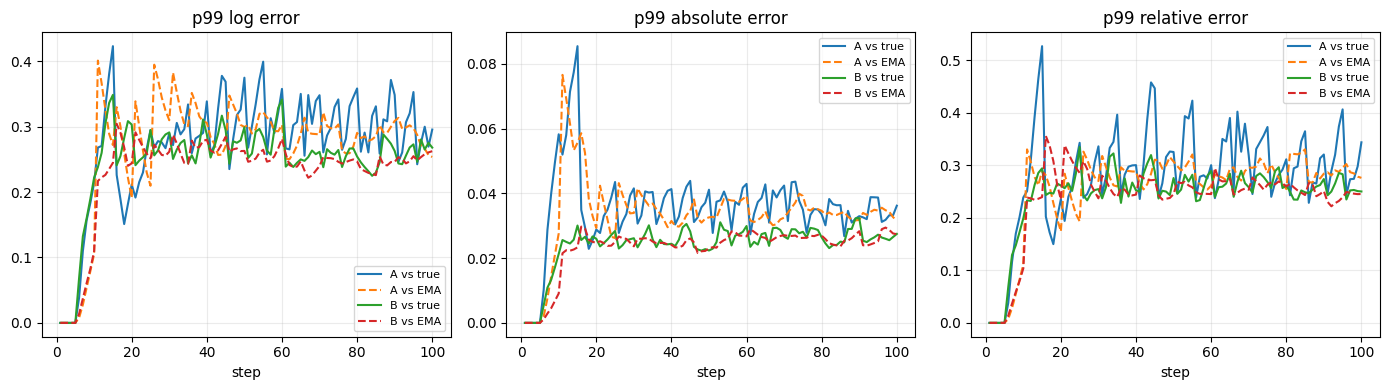

In [3]:
if agg.empty:
    fig, ax = plt.subplots(figsize=(8, 2.6))
    ax.text(0.5, 0.5, "No aggregate error records found", ha="center", va="center")
    ax.set_axis_off()
else:
    err_df = agg[(agg["step"] >= 1) & (agg["n"] == agg["n"].max())].copy()
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
    for side, sub in err_df.groupby("side"):
        by_step = sub.groupby("step", as_index=False)[[
            "log_err_p99", "abs_err_p99", "rel_err_p99",
            "ema_ref_log_err_p99", "ema_ref_abs_err_p99", "ema_ref_rel_err_p99",
            "true_ema_log_err_p99", "true_ema_abs_err_p99", "true_ema_rel_err_p99"
        ]].median(numeric_only=True)
        axes[0].plot(by_step["step"], by_step["abs_err_p99"], label=f"{side} kpar vs true")
        axes[0].plot(by_step["step"], by_step["ema_ref_abs_err_p99"], ls="--", label=f"{side} kpar vs EMA")
        axes[0].plot(by_step["step"], by_step["true_ema_abs_err_p99"], ls=":", label=f"{side} true vs EMA")
        axes[1].plot(by_step["step"], by_step["log_err_p99"], label=f"{side} kpar vs true")
        axes[1].plot(by_step["step"], by_step["ema_ref_log_err_p99"], ls="--", label=f"{side} kpar vs EMA")
        axes[1].plot(by_step["step"], by_step["true_ema_log_err_p99"], ls=":", label=f"{side} true vs EMA")
        axes[2].plot(by_step["step"], by_step["rel_err_p99"], label=f"{side} kpar vs true")
        axes[2].plot(by_step["step"], by_step["ema_ref_rel_err_p99"], ls="--", label=f"{side} kpar vs EMA")
        axes[2].plot(by_step["step"], by_step["true_ema_rel_err_p99"], ls=":", label=f"{side} true vs EMA")
    titles = ["p99 absolute c error", "p99 log c error", "p99 relative c error"]
    for ax, title in zip(axes, titles):
        ax.set_title(title)
        ax.set_xlabel("step")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("absolute c units")
    axes[1].set_ylabel("|log(a / b)|")
    axes[2].set_ylabel("relative error")
    fig.suptitle("Aggregate error: p99 across pairs, median across shape groups", y=1.04)
    fig.tight_layout()
    plt.show()


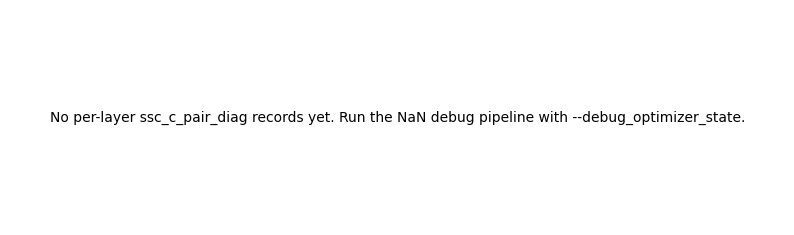

In [4]:
def explode_pair_diag(events):
    records = []
    for e in events:
        if e.get("event") != "ssc_c_pair_diag":
            continue
        names = e.get("pair_names", [])
        indices = e.get("pair_indices", list(range(len(names))))
        for j, name in enumerate(names):
            rec = {
                "step": e.get("step"),
                "side": e.get("side"),
                "n": e.get("n"),
                "refresh_due": e.get("refresh_due"),
                "pair_index": indices[j] if j < len(indices) else j,
                "pair_name": name,
                "source": e.get("source"),
            }
            for key in ("c_used", "c_true", "c_ema", "log_err", "abs_err", "rel_err", "ema_ref_log_err", "ema_ref_abs_err", "ema_ref_rel_err"):
                vals = e.get(key)
                if isinstance(vals, list) and j < len(vals):
                    rec[key] = vals[j]
            records.append(rec)
    return pd.DataFrame(records)

pair_df = explode_pair_diag(events)
if pair_df.empty:
    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.text(
        0.5, 0.5,
        "No per-layer ssc_c_pair_diag records yet. Run the NaN debug pipeline with --debug_optimizer_state.",
        ha="center", va="center", wrap=True,
    )
    ax.set_axis_off()
else:
    pair_df["step"] = pd.to_numeric(pair_df["step"], errors="coerce")
    last_n = pair_df["n"].max()
    view = pair_df[(pair_df["n"] == last_n) & pair_df["c_ema"].notna()].copy()
    score = view.groupby("pair_name")["ema_ref_abs_err"].mean().sort_values(ascending=False)
    chosen = score.head(8).index.tolist()
    fig, axes = plt.subplots(len(chosen), 1, figsize=(12, max(2.2 * len(chosen), 4)), sharex=True)
    if len(chosen) == 1:
        axes = [axes]
    for ax, name in zip(axes, chosen):
        sub = view[view["pair_name"] == name]
        for side, ss in sub.groupby("side"):
            by_step = ss.groupby("step", as_index=False)[["c_true", "c_ema", "c_used"]].median(numeric_only=True)
            ax.plot(by_step["step"], by_step["c_true"], label=f"{side} true")
            ax.plot(by_step["step"], by_step["c_ema"], ls="--", label=f"{side} EMA")
            ax.plot(by_step["step"], by_step["c_used"], ls=":", label=f"{side} kpar")
        ax.set_title(name, fontsize=9)
        ax.set_ylabel("c")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=7, ncols=3)
    axes[-1].set_xlabel("step")
    fig.tight_layout()
    plt.show()


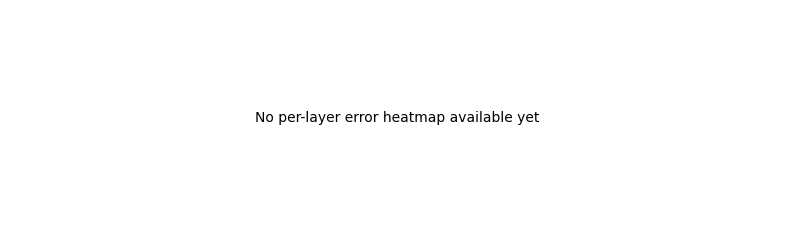

In [5]:
if pair_df.empty:
    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.text(0.5, 0.5, "No per-layer error heatmap available yet", ha="center", va="center")
    ax.set_axis_off()
else:
    last_n = pair_df["n"].max()
    view = pair_df[(pair_df["n"] == last_n) & pair_df["ema_ref_abs_err"].notna()].copy()
    score = view.groupby("pair_name")["ema_ref_abs_err"].mean().sort_values(ascending=False).head(24)
    heat = (
        view[view["pair_name"].isin(score.index)]
        .groupby(["pair_name", "side"])["ema_ref_abs_err"]
        .mean()
        .unstack("side")
        .loc[score.index]
    )
    fig, ax = plt.subplots(figsize=(6, max(5, 0.24 * len(heat))))
    im = ax.imshow(heat.fillna(0.0).to_numpy(), aspect="auto", cmap="magma")
    ax.set_yticks(np.arange(len(heat.index)), labels=heat.index, fontsize=7)
    ax.set_xticks(np.arange(len(heat.columns)), labels=heat.columns)
    ax.set_title("Mean abs error vs EMA by layer")
    fig.colorbar(im, ax=ax, label="|c_used - EMA(c_true)|")
    fig.tight_layout()
    plt.show()
